In [1]:
from collections import defaultdict

import gymnasium as gym
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

In [3]:
env = gym.make("CartPole-v1", render_mode=None)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

In [4]:
visit_counts = defaultdict(int)

discretization:

because +-inf and float vals doesn't fit good into dict

In [5]:
SCALE = 10
SCALE_ANGULAR = 1
eps = 1e-6

BIN_COUNT = 50
u = np.linspace(-1 + eps, 1 - eps, num=BIN_COUNT)
bins_angvel = SCALE_ANGULAR * np.arctanh(u)
bins_vel = SCALE * np.arctanh(u)

bins_cartpos = np.linspace(env.observation_space.low[0], env.observation_space.high[0], num=BIN_COUNT)
bins_poleangle = np.linspace(env.observation_space.low[2], env.observation_space.high[2], num=BIN_COUNT)

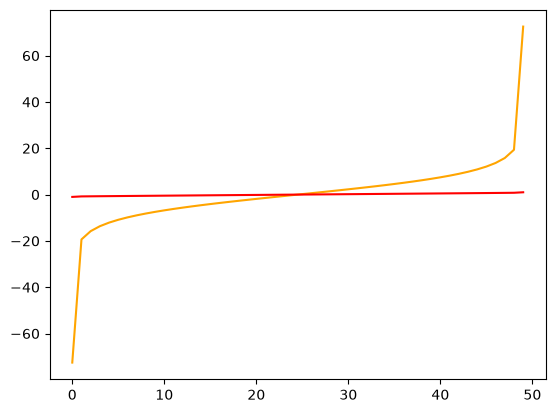

In [6]:
alpha = 0.75  # 0 = pure arctanh, 1 = pure linear
linear_part = u
warped_part = np.arctanh(u) / np.arctanh(1 - eps)  # normalize to similar scale
bins_angvel = SCALE_ANGULAR * (alpha * linear_part + (1 - alpha) * warped_part)

plt.plot([bins_vel[i] for i in range(len(bins_vel))], label="train", color="orange")
plt.plot([bins_angvel[i] for i in range(len(bins_angvel))], label="train", color="red")
plt.show()

In [7]:
def discrete_value(input: float, bins: list[float], bin_count = BIN_COUNT) -> float:
    return min(np.digitize(input, bins), bin_count-1)

In [8]:
class CartAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        self.env = env
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        self.lr = learning_rate
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.training_error = []
        self.discount_factor = discount_factor

    def get_action(self, obs: tuple[float, float, float, float]) -> int:
        obs = self._prepare_input(obs)
        return self.env.action_space.sample() if np.random.random() < self.epsilon else int(np.argmax(self.q_values[obs]))
    
    def update(
        self,
        obs: tuple[float, float, float, float],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[float, float, float, float],
    ):

        obs = self._prepare_input(obs)
        next_obs = self._prepare_input(next_obs)
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        target = reward + self.discount_factor * future_q_value
        temporal_difference = target - self.q_values[obs][action]
        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    @staticmethod
    def _prepare_input(obs: tuple[float, float, float, float]) -> tuple[int, int, int, int]:
        return (
            discrete_value(obs[0], bins_cartpos),
            discrete_value(obs[1], bins_vel),
            discrete_value(obs[2], bins_poleangle),
            discrete_value(obs[3], bins_angvel),
        )

    def decay(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

In [9]:
agent = CartAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [10]:
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        agent.update(obs, action, reward, terminated, next_obs)
        visit_counts[CartAgent._prepare_input(obs)] += 1
        done = terminated or truncated
        obs = next_obs

    agent.decay()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [02:22<00:00, 701.61it/s]


In [11]:
def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

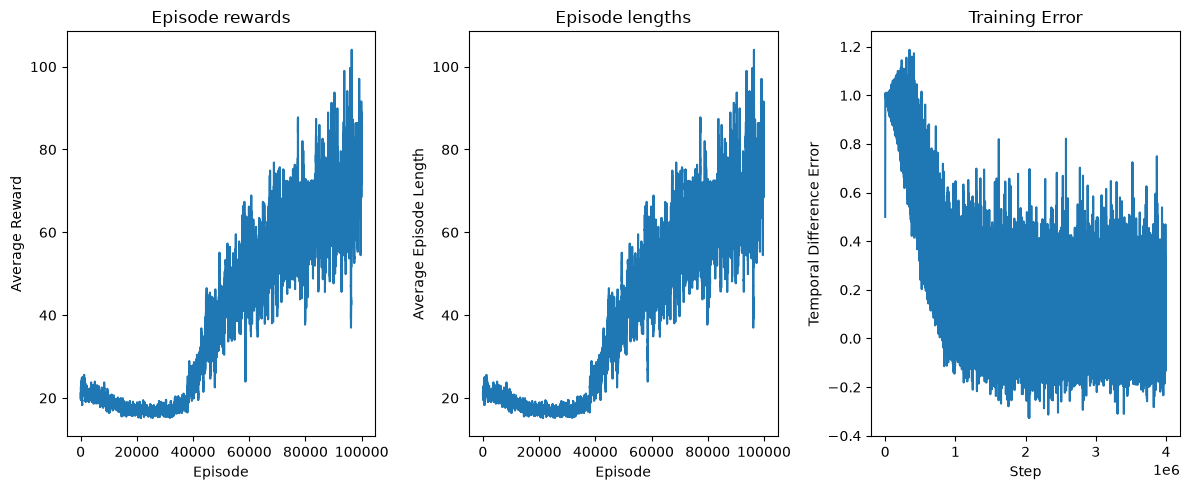

In [12]:
# Smooth over a 100-episode window
rolling_length = 100
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [13]:
len(agent.q_values)

9420

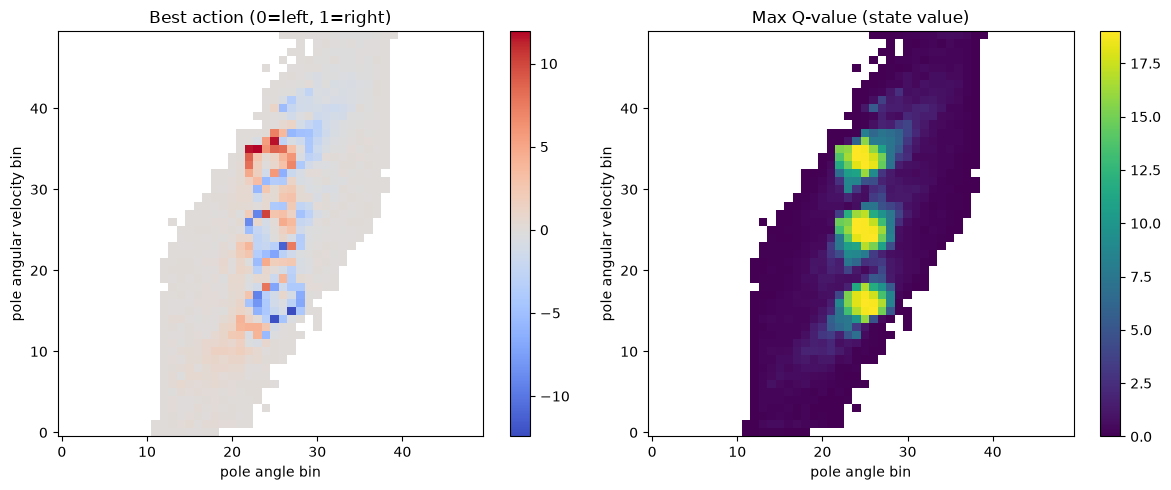

In [14]:
FIXED_CARTPOS_IDX = BIN_COUNT // 2   # pick the most common bin from your histogram
FIXED_VEL_IDX = BIN_COUNT // 2       # same idea
action_grid = np.full((BIN_COUNT, BIN_COUNT), np.nan)
value_grid = np.full((BIN_COUNT, BIN_COUNT), np.nan)

Q = agent.q_values

for angle_idx in range(BIN_COUNT):
    for angvel_idx in range(BIN_COUNT):
        state = (FIXED_CARTPOS_IDX, FIXED_VEL_IDX, angle_idx, angvel_idx)
        if state in Q:  # only plot states actually visited
            q_values = Q[state]
            action_grid[angvel_idx, angle_idx] = Q[state][1] - Q[state][0]
            value_grid[angvel_idx, angle_idx] = np.max(q_values)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(action_grid, origin='lower', cmap='coolwarm', aspect='auto')
axes[0].set_title('Best action (0=left, 1=right)')
axes[0].set_xlabel('pole angle bin')
axes[0].set_ylabel('pole angular velocity bin')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(value_grid, origin='lower', cmap='viridis', aspect='auto')
axes[1].set_title('Max Q-value (state value)')
axes[1].set_xlabel('pole angle bin')
axes[1].set_ylabel('pole angular velocity bin')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

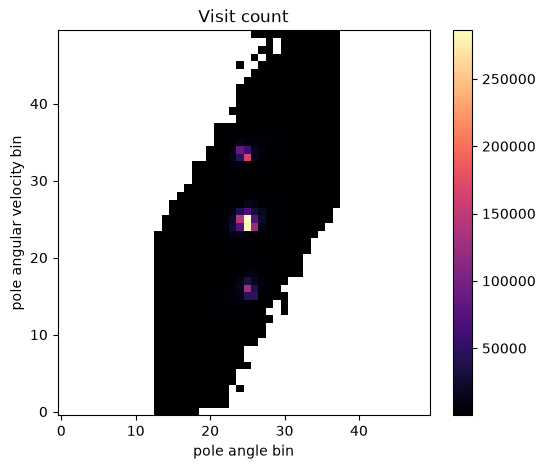

In [15]:
count_grid = np.full((BIN_COUNT, BIN_COUNT), np.nan)

for angle_idx in range(BIN_COUNT):
    for angvel_idx in range(BIN_COUNT):
        state = (FIXED_CARTPOS_IDX, FIXED_VEL_IDX, angle_idx, angvel_idx)
        if state in visit_counts:
            count_grid[angvel_idx, angle_idx] = visit_counts[state]

plt.figure(figsize=(6, 5))
plt.imshow(count_grid, origin='lower', cmap='magma', aspect='auto')
plt.title('Visit count')
plt.xlabel('pole angle bin')
plt.ylabel('pole angular velocity bin')
plt.colorbar()
plt.show()

In [16]:
import pickle

with open("./data/q_table.pkl", "wb") as f:
    pickle.dump(dict(agent.q_values), f)